In [8]:
# CELL 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("=" * 45)
print("  ✅ All libraries loaded successfully")
print("  🛡️  AI Cybersecurity Threat Detection")
print("=" * 45)

  ✅ All libraries loaded successfully
  🛡️  AI Cybersecurity Threat Detection


In [9]:
# CELL 2: Simulate realistic network traffic data
np.random.seed(42)

# --- Normal Traffic (1000 connections) ---
n_normal = 1000
normal_traffic = pd.DataFrame({
    'duration':        np.random.exponential(scale=5.0,  size=n_normal),
    'bytes_sent':      np.random.normal(5000,  1000,     n_normal).clip(min=0),
    'bytes_received':  np.random.normal(8000,  1500,     n_normal).clip(min=0),
    'packets':         np.random.poisson(50,              n_normal),
    'failed_logins':   np.random.poisson(0.5,             n_normal),
    'unique_ports':    np.random.randint(1, 5,            n_normal),
    'label': 0  # 0 = Normal
})

# --- Attack Traffic (100 connections) ---
n_attack = 100
attack_traffic = pd.DataFrame({
    'duration':        np.random.exponential(scale=0.3,  size=n_attack),   # Very short bursts
    'bytes_sent':      np.random.normal(60000, 8000,     n_attack).clip(min=0),  # Massive data exfil
    'bytes_received':  np.random.normal(200,   80,       n_attack).clip(min=0),  # Tiny response
    'packets':         np.random.poisson(600,             n_attack),        # Packet flood
    'failed_logins':   np.random.poisson(12,              n_attack),        # Brute force
    'unique_ports':    np.random.randint(20, 100,         n_attack),        # Port scanning
    'label': 1  # 1 = Attack
})

# --- Combine and Shuffle ---
df = pd.concat([normal_traffic, attack_traffic], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Dataset created: {df.shape[0]} total records")
print(f"   Normal traffic : {(df.label == 0).sum()} records")
print(f"   Attack traffic : {(df.label == 1).sum()} records")
print()
print(df.describe().round(2))

✅ Dataset created: 1100 total records
   Normal traffic : 1000 records
   Attack traffic : 100 records

       duration  bytes_sent  bytes_received  packets  failed_logins  \
count   1100.00     1100.00         1100.00  1100.00        1100.00   
mean       4.45    10107.97         7308.53    99.97           1.55   
std        4.82    16065.63         2646.44   158.81           3.59   
min        0.00     2078.65           13.89    31.00           0.00   
25%        0.87     4504.17         6645.54    46.00           0.00   
50%        2.85     5201.13         7843.10    51.00           0.00   
75%        6.25     6047.71         8902.55    56.00           1.00   
max       40.86    77633.49        12706.62   697.00          23.00   

       unique_ports    label  
count       1100.00  1100.00  
mean           7.63     0.09  
std           17.85     0.29  
min            1.00     0.00  
25%            1.00     0.00  
50%            3.00     0.00  
75%            4.00     0.00  
max     

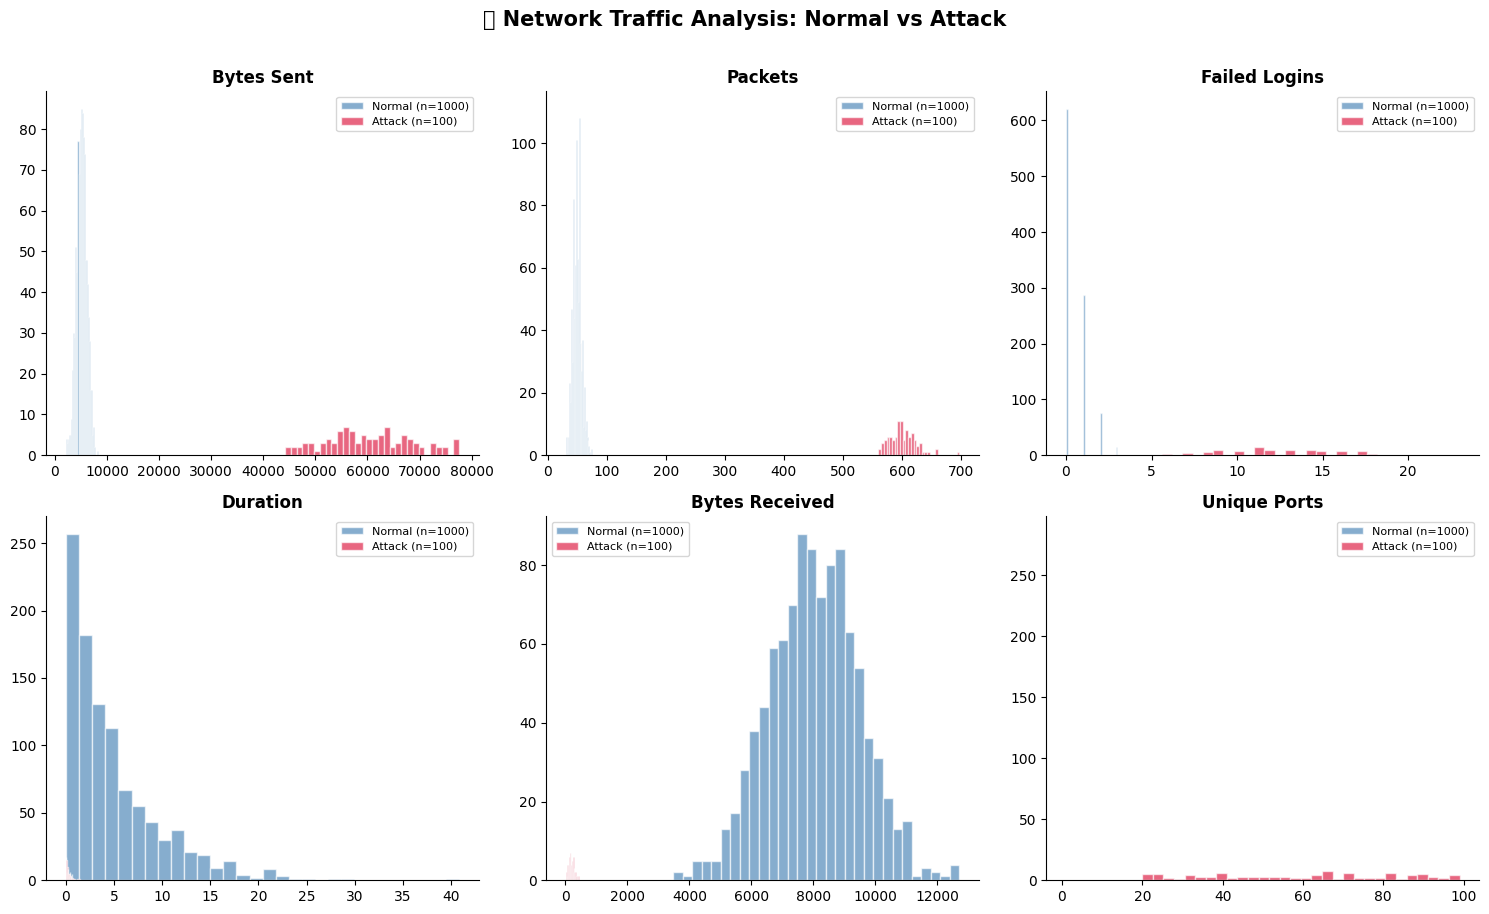

✅ EDA plot saved as 'eda_plot.png'


In [10]:
# CELL 3: Visualize the data - Normal vs Attack patterns
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('🔍 Network Traffic Analysis: Normal vs Attack', 
             fontsize=15, fontweight='bold', y=1.01)

features   = ['bytes_sent', 'packets', 'failed_logins', 
               'duration', 'bytes_received', 'unique_ports']
colors_n   = 'steelblue'
colors_a   = 'crimson'

for ax, feat in zip(axes.flatten(), features):
    normal_vals = df[df.label == 0][feat]
    attack_vals = df[df.label == 1][feat]
    
    ax.hist(normal_vals, bins=30, alpha=0.65, color=colors_n, 
            label=f'Normal (n={len(normal_vals)})', edgecolor='white')
    ax.hist(attack_vals, bins=30, alpha=0.65, color=colors_a,  
            label=f'Attack (n={len(attack_vals)})', edgecolor='white')
    
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved as 'eda_plot.png'")

In [11]:
# CELL 4: Train two models — unsupervised + supervised

FEATURES = ['duration', 'bytes_sent', 'bytes_received', 
            'packets', 'failed_logins', 'unique_ports']

X = df[FEATURES]
y = df['label']

# --- Scale features ---
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── MODEL 1: Isolation Forest (Unsupervised Anomaly Detection) ──────────────
iso_model = IsolationForest(contamination=0.09, random_state=42, n_estimators=100)
iso_preds = iso_model.fit_predict(X_scaled)
# Isolation Forest returns: 1 = normal, -1 = anomaly → convert to 0/1
df['iso_prediction'] = np.where(iso_preds == -1, 1, 0)

# ── MODEL 2: Random Forest (Supervised Classification) ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Store test results
df_test           = df.iloc[y_test.index].copy()
df_test['rf_pred'] = rf_preds
df_test['actual']  = y_test.values

# Print results
print("=" * 50)
print("  MODEL 1: Isolation Forest (Unsupervised)")
print("=" * 50)
print(f"  Threats flagged   : {df['iso_prediction'].sum()}")
print(f"  Normal flagged    : {(df['iso_prediction'] == 0).sum()}")

print()
print("=" * 50)
print("  MODEL 2: Random Forest (Supervised)")
print("=" * 50)
print(f"  Test set accuracy : {accuracy_score(y_test, rf_preds)*100:.2f}%")
print()
print(classification_report(y_test, rf_preds, 
                             target_names=['Normal', 'Attack']))

  MODEL 1: Isolation Forest (Unsupervised)
  Threats flagged   : 99
  Normal flagged    : 1001

  MODEL 2: Random Forest (Supervised)
  Test set accuracy : 100.00%

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       250
      Attack       1.00      1.00      1.00        25

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



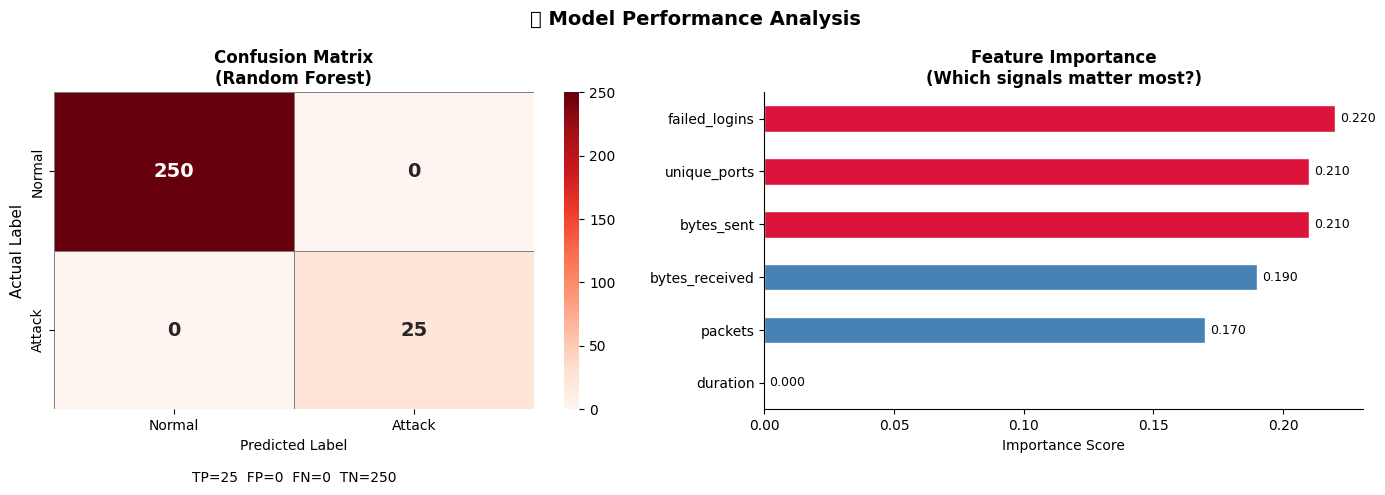

✅ Model performance plot saved as 'model_performance.png'


In [12]:
# CELL 5: Visualize model performance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Model Performance Analysis', fontsize=14, fontweight='bold')

# ── Plot 1: Confusion Matrix (Random Forest) ───────────────────────────────
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix\n(Random Forest)', fontweight='bold')
axes[0].set_ylabel('Actual Label',    fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Add annotation guide
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'Predicted Label\n\nTP={tp}  FP={fp}  FN={fn}  TN={tn}', fontsize=10
)

# ── Plot 2: Feature Importance (Random Forest) ─────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

colors = ['crimson' if i > importances.median() else 'steelblue' 
          for i in importances]
importances.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Feature Importance\n(Which signals matter most?)', 
                   fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].spines[['top', 'right']].set_visible(False)

for i, v in enumerate(importances):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model performance plot saved as 'model_performance.png'")

  🚨 REAL-TIME THREAT DETECTION LOG
  #     bytes_sent   packets  failed_logins  unique_ports    VERDICT
------------------------------------------------------------
  1          59709       581             12            59  🚨 THREAT
  2          62396       597              7            36  🚨 THREAT
  3          52606       660             15            90  🚨 THREAT
  4          69461       597              7            54  🚨 THREAT
  5          69568       638             11            82  🚨 THREAT
  6          55699       597              9            66  🚨 THREAT
  7          55594       618             14            54  🚨 THREAT
  8          66889       628             15            83  🚨 THREAT
  9          63656       614             12            93  🚨 THREAT
  10         65525       578             14            88  🚨 THREAT
  11         53969       697             12            91  🚨 THREAT
  12         61422       598             12            45  🚨 THREAT
  13         58112 

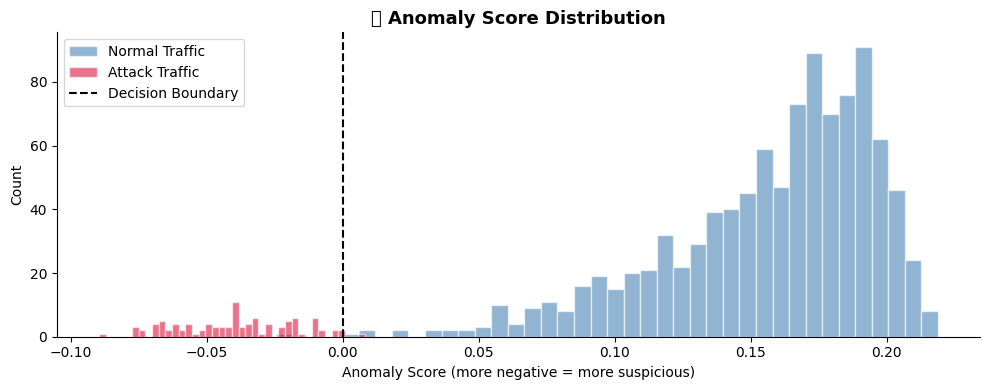

✅ Anomaly score plot saved as 'anomaly_scores.png'


In [13]:
# CELL 6: Simulate real-time threat detection and generate alert table

print("=" * 60)
print("  🚨 REAL-TIME THREAT DETECTION LOG")
print("=" * 60)
print(f"  {'#':<4} {'bytes_sent':>11} {'packets':>9} {'failed_logins':>14} "
      f"{'unique_ports':>13} {'VERDICT':>10}")
print("-" * 60)

# Run Isolation Forest on all records and print flagged ones
detected = df[df['iso_prediction'] == 1][FEATURES + ['iso_prediction']].head(15)

alert_count = 0
for idx, row in detected.iterrows():
    alert_count += 1
    verdict = "🚨 THREAT"
    print(f"  {alert_count:<4} {row['bytes_sent']:>11.0f} {row['packets']:>9.0f} "
          f"{row['failed_logins']:>14.0f} {row['unique_ports']:>13.0f}  {verdict}")

print("-" * 60)
print(f"  Total threats flagged: {df['iso_prediction'].sum()} / {len(df)}")
print("=" * 60)

# ── Threat Score Distribution Plot ─────────────────────────────────────────
plt.figure(figsize=(10, 4))
scores = iso_model.decision_function(X_scaled)  # More negative = more anomalous

plt.hist(scores[df.label == 0], bins=40, alpha=0.6, 
         color='steelblue', label='Normal Traffic', edgecolor='white')
plt.hist(scores[df.label == 1], bins=40, alpha=0.6, 
         color='crimson',   label='Attack Traffic', edgecolor='white')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Decision Boundary')
plt.title('🔍 Anomaly Score Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Anomaly Score (more negative = more suspicious)')
plt.ylabel('Count')
plt.legend()
plt.spines  = plt.gca().spines
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Anomaly score plot saved as 'anomaly_scores.png'")

In [14]:
# CELL 7: Final project summary dashboard

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, rf_preds)
recall    = recall_score(y_test, rf_preds)
f1        = f1_score(y_test, rf_preds)
accuracy  = accuracy_score(y_test, rf_preds)

print()
print("╔══════════════════════════════════════════════════╗")
print("║    🛡️  AI CYBERSECURITY THREAT DETECTION          ║")
print("║           FINAL PROJECT REPORT                   ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Dataset                                          ║")
print(f"║    Total records      : {len(df):<5}                    ║")
print(f"║    Normal connections : {(df.label==0).sum():<5}                    ║")
print(f"║    Attack events      : {(df.label==1).sum():<5}                    ║")
print(f"║    Features used      : {len(FEATURES):<5}                    ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Model 1: Isolation Forest (Unsupervised)         ║")
print(f"║    Threats Flagged    : {df['iso_prediction'].sum():<5}                    ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Model 2: Random Forest (Supervised)              ║")
print(f"║    Accuracy           : {accuracy*100:>5.1f}%                  ║")
print(f"║    Precision          : {precision*100:>5.1f}%                  ║")
print(f"║    Recall             : {recall*100:>5.1f}%                  ║")
print(f"║    F1-Score           : {f1*100:>5.1f}%                  ║")
print("╠══════════════════════════════════════════════════╣")
print("║  Output Files                                     ║")
print("║    ✅ eda_plot.png                                 ║")
print("║    ✅ model_performance.png                        ║")
print("║    ✅ anomaly_scores.png                           ║")
print("╠══════════════════════════════════════════════════╣")
print("║  STATUS: ✅ PROJECT COMPLETE — READY FOR GITHUB   ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║    🛡️  AI CYBERSECURITY THREAT DETECTION          ║
║           FINAL PROJECT REPORT                   ║
╠══════════════════════════════════════════════════╣
║  Dataset                                          ║
║    Total records      : 1100                     ║
║    Normal connections : 1000                     ║
║    Attack events      : 100                      ║
║    Features used      : 6                        ║
╠══════════════════════════════════════════════════╣
║  Model 1: Isolation Forest (Unsupervised)         ║
║    Threats Flagged    : 99                       ║
╠══════════════════════════════════════════════════╣
║  Model 2: Random Forest (Supervised)              ║
║    Accuracy           : 100.0%                  ║
║    Precision          : 100.0%                  ║
║    Recall             : 100.0%                  ║
║    F1-Score           : 100.0%                  ║
╠════════════════════════════════════════════

In [1]:
import os
print(os.getcwd())

C:\Users\Ashwini
